## Lagos Air Quality Capstone Project

**Goal** 
1. Clean Lagos air quality data to ensure an effective prediction model.
2. Examine and visualize the relationship of key factors affecting **PM2.5 levels**

**Dataset:**
Lagos Air Quality December 2025

**Data Source:** OpenAFRICA (https://open.africa/dataset/sensorsafrica-airquality-archive-lagos)

**Note**: This notebook also contains code pertaining to data visualization


## PM2.5 ##

PM2.5 levels refer to the concentration of fine particulate matter in the air that has a diameter of 2.5 micrometers or smaller.

These particles are so small that they can:
1. Penetrate deep into the lungs
2. Enter the bloodstream
3. Increase risk of asthma, heart disease, and respiratory illness

These health concerns have made it paramount to understand what influences these emissions and which controllable factors can be used to control it

In [1]:
#loading necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")


## Data Collection and Cleaning

In [2]:
#loading csv file
#csv file was download from data source stated above
df = pd.read_csv('Lagos Air Quality December 2025.csv')
df.head()

,sensor_id;sensor_type;location;lat;lon;timestamp;value_type;value
0,4854;DHT22;3628;6.559;3.386;2025-12-01T00:02:2...
1,4854;DHT22;3628;6.559;3.386;2025-12-01T00:02:2...
2,4854;DHT22;3628;6.559;3.386;2025-12-01T00:08:0...
3,4854;DHT22;3628;6.559;3.386;2025-12-01T00:08:0...
4,4853;pms5003;3628;6.559;3.386;2025-12-01T00:13...


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11065 entries, 0 to 11064
Data columns (total 1 columns):
 #   Column                                                             Non-Null Count  Dtype 
---  ------                                                             --------------  ----- 
 0   sensor_id;sensor_type;location;lat;lon;timestamp;value_type;value  11065 non-null  object
dtypes: object(1)
memory usage: 86.6+ KB


The dataset has just one column with each value in a row separated by **';'** 

This can be used as the demarcator for the split into new columns but rather than using split() a less tedious method would be adding **sep=';'** to the read_csv function

In [4]:
df = pd.read_csv('Lagos Air Quality December 2025.csv', sep=';')

# Convert types and handle inconsistent ISO formats
df['timestamp'] = pd.to_datetime(df['timestamp'], format='mixed')
df['value'] = pd.to_numeric(df['value'], errors='coerce')

#Filter for the Maryland sensor (lat: 6.559, lon: 3.386)
lagos_df = df[np.isclose(df['lat'], 6.559) & np.isclose(df['lon'], 3.386)].copy()
lagos_df.head()

,sensor_id,sensor_type,location,lat,lon,timestamp,value_type,value
0,4854,DHT22,3628,6.559,3.386,2025-12-01 00:02:26.374143+00:00,humidity,89.1
1,4854,DHT22,3628,6.559,3.386,2025-12-01 00:02:26.374143+00:00,temperature,30.3
2,4854,DHT22,3628,6.559,3.386,2025-12-01 00:08:00.971909+00:00,humidity,88.8
3,4854,DHT22,3628,6.559,3.386,2025-12-01 00:08:00.971909+00:00,temperature,30.4
4,4853,pms5003,3628,6.559,3.386,2025-12-01 00:13:18.385363+00:00,P2,39.5


I realised the date format of this timestamp was not typical, so the format was specified to mixed to accomodate the unconventionality

The dataset was filtered to only include Maryland sensor data (lat: 6.559, lon: 3.386) because there is not enough (4 rows) data of the other location (Victoria Island) to get a quality prediction

In [5]:
lagos_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11043 entries, 0 to 11064
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype              
---  ------       --------------  -----              
 0   sensor_id    11043 non-null  int64              
 1   sensor_type  11043 non-null  object             
 2   location     11043 non-null  int64              
 3   lat          11043 non-null  float64            
 4   lon          11043 non-null  float64            
 5   timestamp    11043 non-null  datetime64[ns, UTC]
 6   value_type   11043 non-null  object             
 7   value        11036 non-null  float64            
dtypes: datetime64[ns, UTC](1), float64(3), int64(2), object(2)
memory usage: 776.5+ KB


In [6]:
# Checking for data shape (rows and columns)
lagos_df.shape

(11043, 8)

In [7]:
# Checking for missing values
lagos_df.isnull().sum()

sensor_id      0
sensor_type    0
location       0
lat            0
lon            0
timestamp      0
value_type     0
value          7
dtype: int64

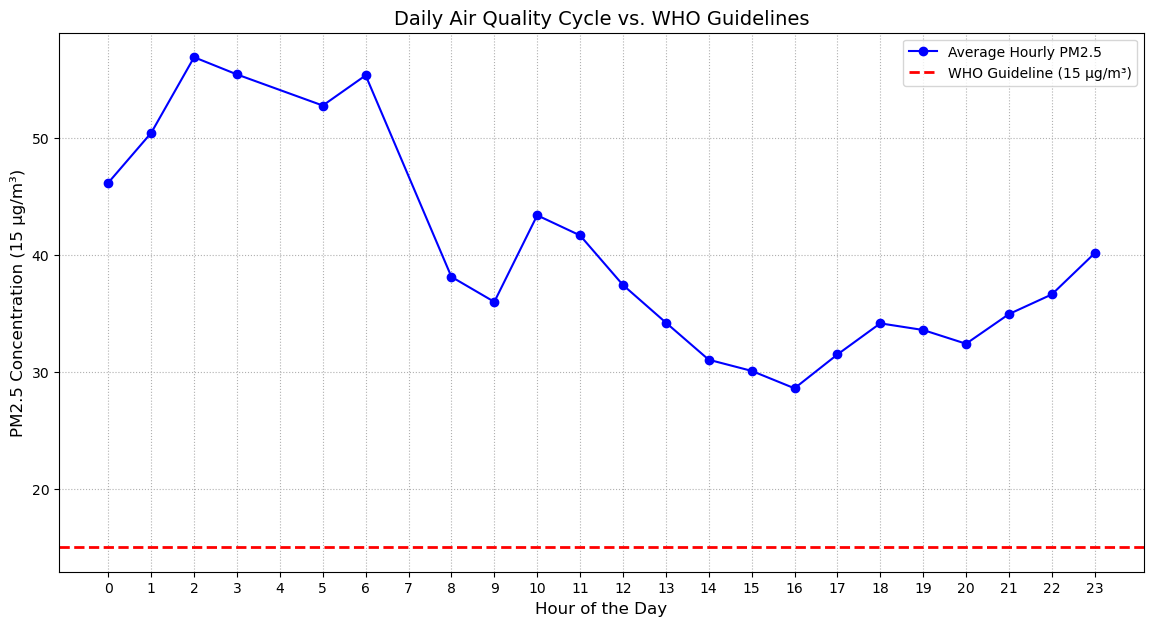

In [8]:
# Filter specifically for PM2.5 Values (P2)
pm25_df = lagos_df[lagos_df['value_type'] == 'P2'].copy()

# Extract the hour from the timestamp
pm25_df['hour'] = pm25_df['timestamp'].dt.hour
# Calculate the average value every day
hourly_avg = pm25_df.groupby('hour')['value'].mean()

plt.figure(figsize=(14, 7))
plt.plot(hourly_avg.index, hourly_avg.values, marker='o', color='blue', label='Average Hourly PM2.5')

plt.axhline(y=15, color='red', linestyle='--', linewidth=2, label='WHO Guideline (15 µg/m³)')

plt.xticks(range(24))
plt.title('Daily Air Quality Cycle vs. WHO Guidelines', fontsize=14)
plt.xlabel('Hour of the Day', fontsize=12)
plt.ylabel('PM2.5 Concentration (15 µg/m³)', fontsize=12)
plt.grid(linestyle=':')
plt.legend()
plt.savefig('Air Quality vs WHO.png')
plt.show()

## Observation

The graph above displays the Average PM2.5 values every hour of the day compared to the WHO guidelines standard (15 µg/m³)

Lagos treads dangerously above guideline level with the lowest value being 29 µg/m³ during 16:00 (or 4PM WAT)

Peak periods occur early in the morning around 1:00 - 6:00 with 2:00 (2AM) have the highest average PM2.5 levels

Also, The fluctuating values of the graph proves time is a key factor of PM2.5 values and essential to get an accurate prediction mode

## Factors Affecting PM2.5 levels

The current dataset is not ideal to analyse factors affecting PM2.5 values but it has the required data needed with the value_type and value columns.

Thus, a new dataset will be created using these values to enable efficient analysis and visualizations

In [9]:
# Pivot metrics to columns
lagos_pivot = lagos_df.pivot_table(index='timestamp', columns='value_type', values='value', aggfunc='first')
lagos_pivot.rename(columns={'P2': 'PM2.5', 'P1': 'PM10', 'temperature': 'Temp', 'humidity': 'Humidity'}, inplace=True)

lagos_pivot

value_type,P0,PM10,PM2.5,Humidity,Temp
timestamp,,,,,
2025-12-01 00:02:26.374143+00:00,NaN,NaN,NaN,89.1,30.3
2025-12-01 00:08:00.971909+00:00,NaN,NaN,NaN,88.8,30.4
2025-12-01 00:13:18.385363+00:00,25.75,49.0,39.5,NaN,NaN
2025-12-01 00:13:35.715886+00:00,NaN,NaN,NaN,89.2,30.3
2025-12-01 00:24:06.029634+00:00,29.00,51.0,43.0,NaN,NaN
...,...,...,...,...,...
2025-12-31 21:05:09.560384+00:00,20.00,30.2,29.0,NaN,NaN
2025-12-31 21:05:27.005416+00:00,NaN,NaN,NaN,85.5,31.4
2025-12-31 21:10:50.643323+00:00,NaN,NaN,NaN,85.3,31.4


In [10]:
#Checking missing values
lagos_pivot.isnull().sum()

value_type
P0          2205
PM10        2208
PM2.5       2207
Humidity    2212
Temp        2212
dtype: int64

In [11]:
#Resample to hourly averages 
hourly_df = lagos_pivot[['PM2.5', 'PM10', 'Temp', 'Humidity']].resample('H').mean()
#interpolate missing gaps
hourly_df = hourly_df.interpolate(method='linear')
hourly_df

value_type,PM2.5,PM10,Temp,Humidity
timestamp,,,,
2025-12-01 00:00:00+00:00,41.250000,50.000000,30.325000,89.050000
2025-12-01 01:00:00+00:00,41.350000,50.600000,30.100000,90.560000
2025-12-01 02:00:00+00:00,41.450000,51.200000,29.875000,92.070000
2025-12-01 03:00:00+00:00,41.550000,51.800000,29.650000,93.580000
2025-12-01 04:00:00+00:00,41.650000,52.400000,29.425000,95.090000
...,...,...,...,...
2025-12-31 17:00:00+00:00,27.487500,36.350000,32.575000,78.600000
2025-12-31 18:00:00+00:00,29.381250,35.300000,31.850000,82.200000
2025-12-31 19:00:00+00:00,30.394444,36.444444,31.544444,84.388889


In [12]:
hourly_df

value_type,PM2.5,PM10,Temp,Humidity
timestamp,,,,
2025-12-01 00:00:00+00:00,41.250000,50.000000,30.325000,89.050000
2025-12-01 01:00:00+00:00,41.350000,50.600000,30.100000,90.560000
2025-12-01 02:00:00+00:00,41.450000,51.200000,29.875000,92.070000
2025-12-01 03:00:00+00:00,41.550000,51.800000,29.650000,93.580000
2025-12-01 04:00:00+00:00,41.650000,52.400000,29.425000,95.090000
...,...,...,...,...
2025-12-31 17:00:00+00:00,27.487500,36.350000,32.575000,78.600000
2025-12-31 18:00:00+00:00,29.381250,35.300000,31.850000,82.200000
2025-12-31 19:00:00+00:00,30.394444,36.444444,31.544444,84.388889


In [13]:
#Checking missing values
hourly_df.isnull().sum()

value_type
PM2.5       0
PM10        0
Temp        0
Humidity    0
dtype: int64

Lag data will be added to the data set.
Lagging data means a delay is created in the data set by shifting a data by x periods. In this case, The model will compare its predictions with what happened an hour ago.
If the prediction and the reality are close, then it's a good mode

Additionally, an **hour** column will be created due to my findings from the previous graph

In [14]:
#Lag feature: using previous hours to predict future ones
hourly_df['hour'] = hourly_df.index.hour
hourly_df['pm25_lag_1'] = hourly_df['PM2.5'].shift(1)  
hourly_df['pm25_lag_2'] = hourly_df['PM2.5'].shift(2)
hourly_df['temp_lag_1'] = hourly_df['Temp'].shift(1)

#since the lag data has been added this means there are rows that missing values because there was no data to shift
#these rows are dropped
data = hourly_df.dropna()

data

value_type,PM2.5,PM10,Temp,Humidity,hour,pm25_lag_1,pm25_lag_2,temp_lag_1
timestamp,,,,,,,,
2025-12-01 02:00:00+00:00,41.450000,51.200000,29.875000,92.070000,2,41.350000,41.250000,30.100000
2025-12-01 03:00:00+00:00,41.550000,51.800000,29.650000,93.580000,3,41.450000,41.350000,29.875000
2025-12-01 04:00:00+00:00,41.650000,52.400000,29.425000,95.090000,4,41.550000,41.450000,29.650000
2025-12-01 05:00:00+00:00,41.750000,53.000000,29.200000,96.600000,5,41.650000,41.550000,29.425000
2025-12-01 06:00:00+00:00,39.812500,49.750000,30.150000,92.400000,6,41.750000,41.650000,29.200000
...,...,...,...,...,...,...,...,...
2025-12-31 17:00:00+00:00,27.487500,36.350000,32.575000,78.600000,17,23.833333,27.407143,34.900000
2025-12-31 18:00:00+00:00,29.381250,35.300000,31.850000,82.200000,18,27.487500,23.833333,32.575000
2025-12-31 19:00:00+00:00,30.394444,36.444444,31.544444,84.388889,19,29.381250,27.487500,31.850000


## Visualization of Factors affecting PM2.5 Levels

<Figure size 1000x600 with 0 Axes>

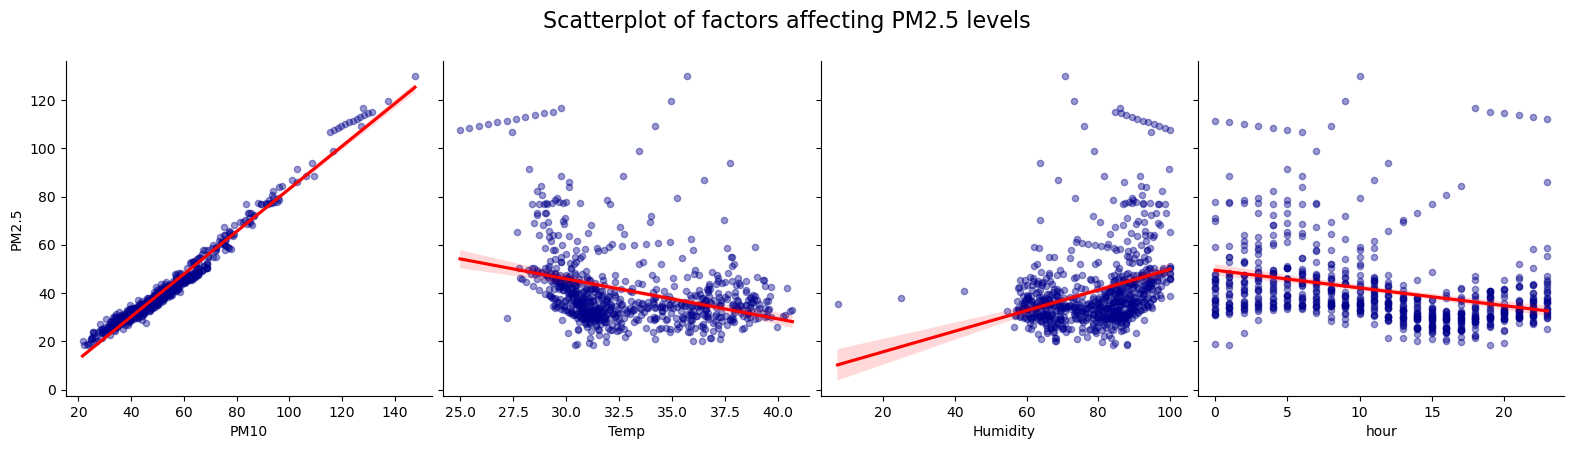

In [15]:
plt.figure(figsize=(10, 6))

PM_plot = sns.pairplot(
    data=data,
    x_vars=['PM10', 'Temp', 'Humidity','hour'],
    y_vars=['PM2.5'],
    kind='reg',     
    height=4,        
    aspect=1,
    plot_kws={
        'line_kws':{'color':'red'}, 
        'scatter_kws': {'alpha': 0.4, 's': 20, 'color': 'darkblue'} 
    }
)

PM_plot.fig.suptitle('Scatterplot of factors affecting PM2.5 levels', y=1.1, fontsize=16)

plt.savefig('focused_pm25_analysis.png', bbox_inches='tight')
plt.show()

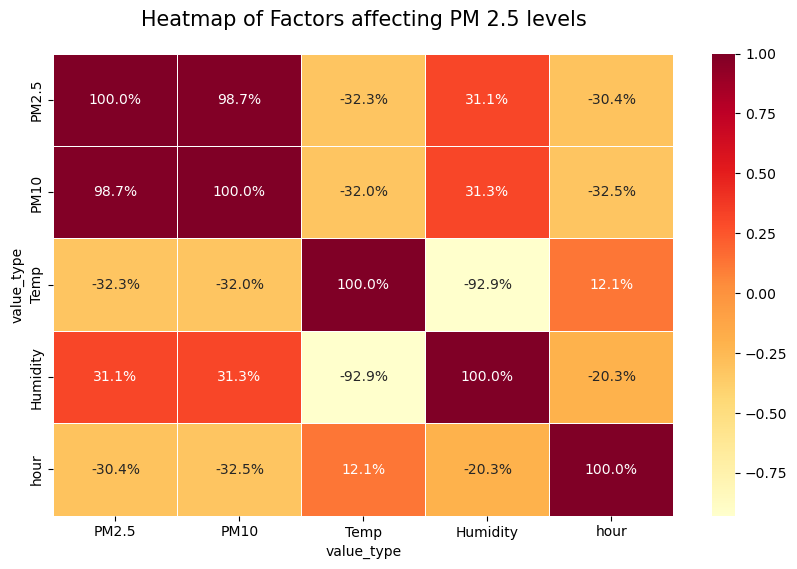

In [16]:
correlation_hour = data[['PM2.5','PM10','Temp','Humidity','hour']].corr()

correlation_hour

plt.figure(figsize=(10, 6))

sns.heatmap(correlation_hour, 
            annot=True, 
            fmt='.1%',      
            cmap='YlOrRd',  
            linewidths=.5,   
           )

plt.title("Heatmap of Factors affecting PM 2.5 levels", fontsize=15, pad=20)

plt.show()

The scatterplot and heatmap visualize the relationship each feature has with the PM2.5 Levels

**PM10(Particulate Matter 10)** : Is very similar to PM2.5 but is slightly bigger and can be found in dust from construction sites, landfills and agriculture, wildfires and brush/waste burning, industrial sources, wind-blown dust from open lands. 

PM10 has a strong positive relationship with PM2.5 levels and positive correlation of 98.7%



**Temp(Temperature)**: Temperature has an inverse relationship with PM2.5 levels and a negative correlation of -32.3%

During the daytime in Lagos, solar heating warms the ground, causing air to rise and carry PM2.5 particles upward. This vertical mixing disperses pollution away from ground level, leading to lower PM2.5 levels.

At night and in the early morning, the ground cools and traps denser air near the surface beneath warmer air above. This “lid” limits air mixing, allowing emissions from generators and traffic to accumulate and increase PM2.5 levels.




**Humidity**: Humidity has a positive relationship with PM2.5 levels

Many PM2.5 particles are "hygroscopic," meaning they love water. In high humidity (as shown in the Lagos graph), these particles absorb moisture from the air. They swell in size and become "sticky," making it easier for them to trap other pollutants.



**Hour**: Hour has an inverse relationship with PM2.5 levels and a negative correlation of -30.4%
As stated previously, the highest PM2.5 levels were around 1-6am so an increase in time leading to a decrease in PM2.5 levels is no surprise.

But it would seek counterintuitive to expect peak period when most people are sleeping. So why is that?


The lies in the seasonal effect of December as this is when harmattan typically starts  During Harmattan, the air is much drier. Without rain to "wash" the air PM2.5 stays suspended for much longer.

Another seasonal effect is **Detty December** which is a popular event in Lagos characterised by constant nightly events and activities causing traffic and congestionat periods past midnight




In [17]:
data.to_csv('cleaned_data.csv', index=False)

print(f"CSV file 'cleaned_data.csv' has been created successfully using pandas.")


CSV file 'cleaned_data.csv' has been created successfully using pandas.


## Data Preparation Summary

1. Collect data from a credible source (API, CSV, web data, open datasets): Extraction of dataset from OpenAFRICA

2. Handle missing values and inconsistencies: Cleaned data by separating the single column into 8 columns and changing the time stamp to date format as well changing data type in columns were necessary

3. Perform basic feature engineering: Created a new table to summarize data of the value type column and created a new hour column that will be used as a feature for the model.


4. Justify cleaning decisions: Creating a new pivot table shifted the focus of the dataset to the target (PM2.5) and its features ('PM10', 'Humidity', 'Temp','Hour').

    Created a graph to show how PM 2.5 values are strongly influenced by the hour of the day, justifying my decision to create a new hour column

    Created new columns for lagging features as they are essential to predict values when working with time series data.


Additionally: This notebook was also used for data visualisations
